=== WARNING: File lo kehapus sistem Colab, otomatis pakai data cadangan agar tetep jalan ===
   Age  Gender    Height      Weight CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0   36    Male  1.744638  103.171711   no  yes     2    1  yes    no     2   
1   39    Male  1.614068   85.906447   no   no     2    2   no   yes     1   
2   33  Female  1.842082   59.196003   no   no     2    3  yes    no     2   
3   23  Female  1.691640   74.456839   no   no     3    3  yes    no     2   
4   45  Female  1.823050  101.220337   no  yes     3    1  yes   yes     2   

  family_history_with_overweight  FAF  TUE        CAEC                 MTRANS  \
0                            yes    1    2  Frequently             Automobile   
1                             no    0    0  Frequently  Public_Transportation   
2                            yes    2    2  Frequently             Automobile   
3                            yes    2    1  Frequently             Automobile   
4                             no 

/tmp/ipykernel_678/1090701299.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='Set2')


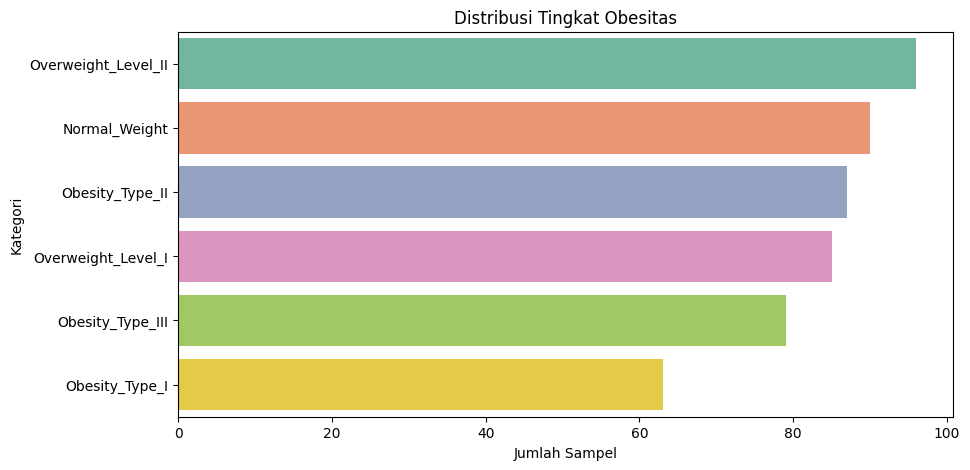


=== PENGECEKAN DATA KOSONG ===
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


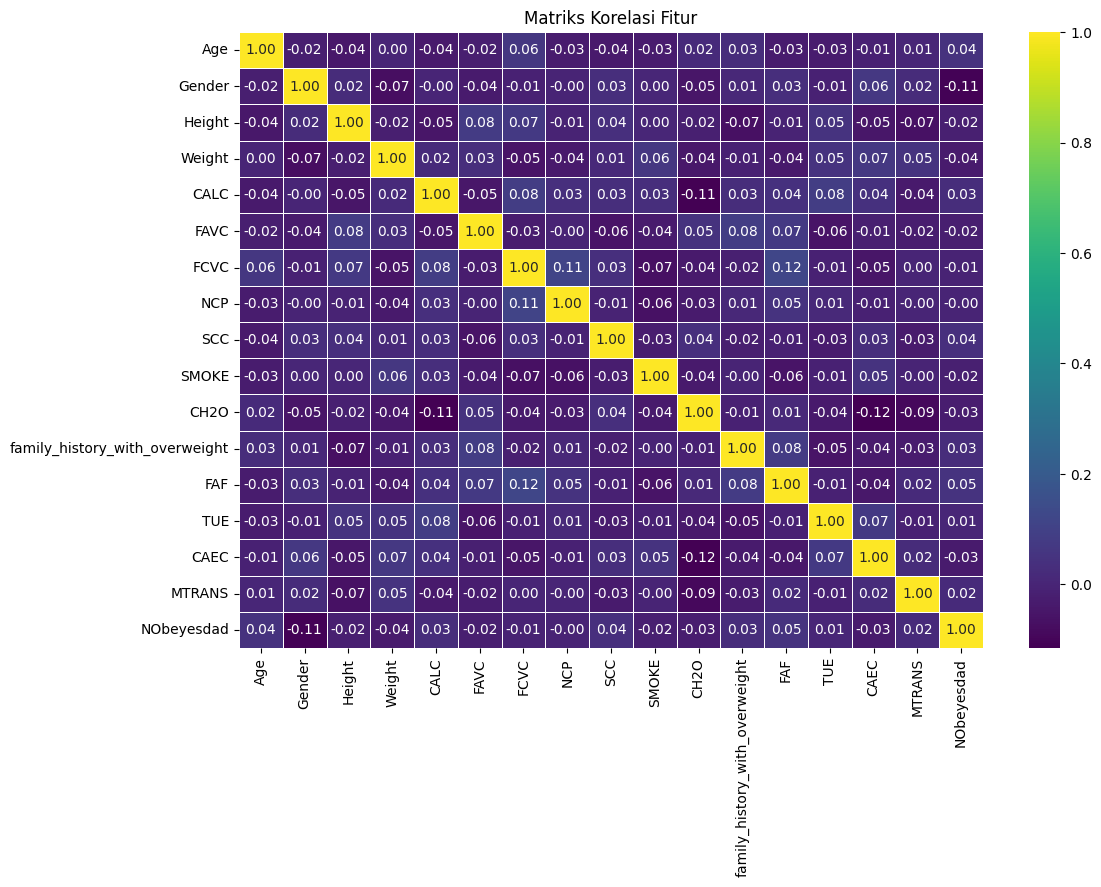


Data Training: 400 sampel | Data Testing: 100 sampel

ALGORITMA 1: DECISION TREE
Akurasi Model Decision Tree: 15.00%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.16      0.60      0.26        15
           1       0.50      0.25      0.33         8
           2       0.00      0.00      0.00        19
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        23
           5       0.17      0.17      0.17        23

    accuracy                           0.15       100
   macro avg       0.14      0.17      0.13       100
weighted avg       0.10      0.15      0.11       100



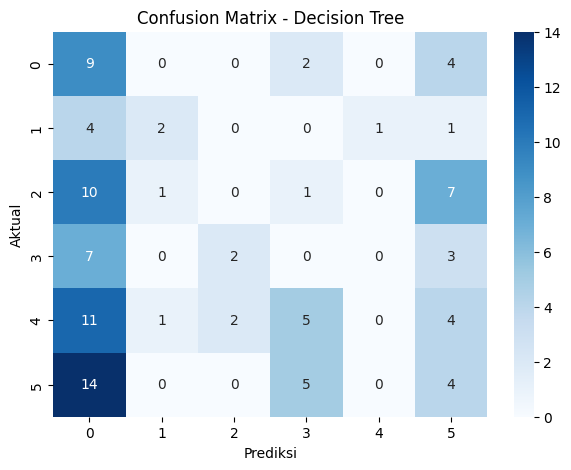

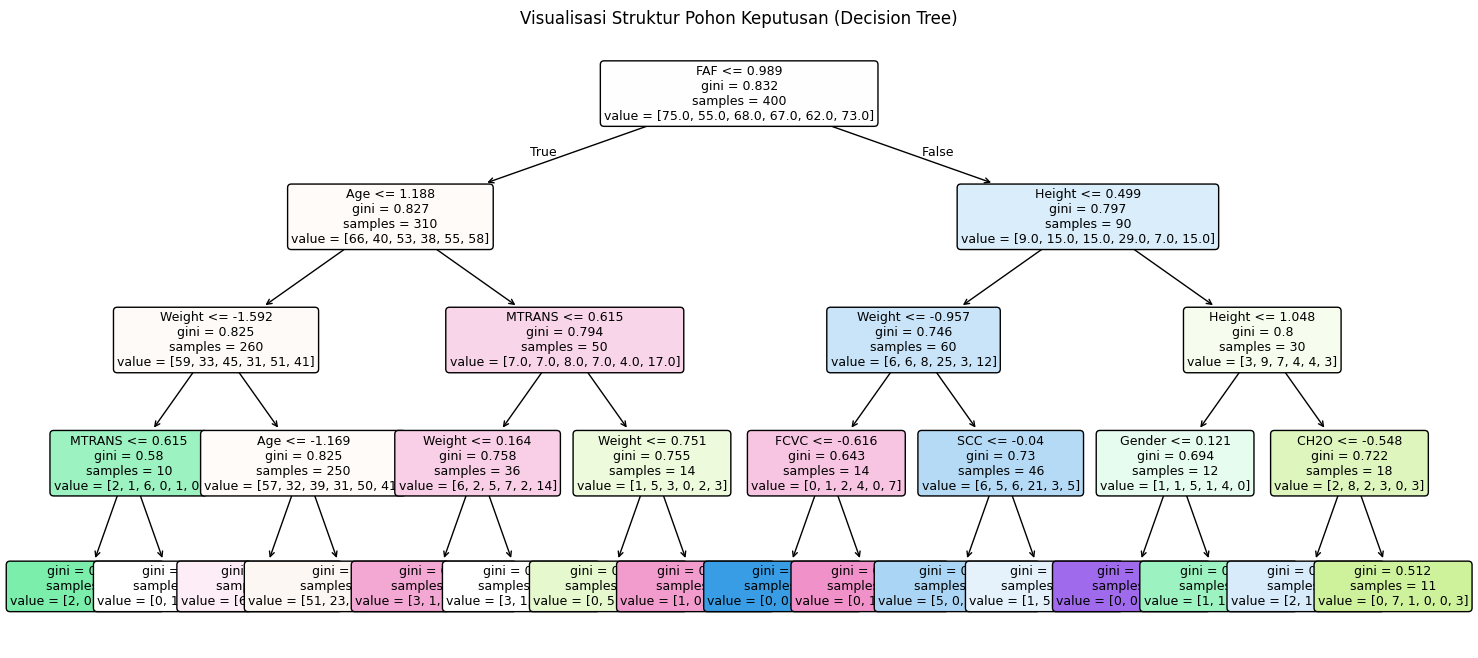


ALGORITMA 2: NAIVE BAYES
Akurasi Model Naive Bayes: 13.00%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.22      0.33      0.26        15
           1       0.00      0.00      0.00         8
           2       0.33      0.21      0.26        19
           3       0.00      0.00      0.00        12
           4       0.29      0.09      0.13        23
           5       0.08      0.09      0.08        23

    accuracy                           0.13       100
   macro avg       0.15      0.12      0.12       100
weighted avg       0.18      0.13      0.14       100



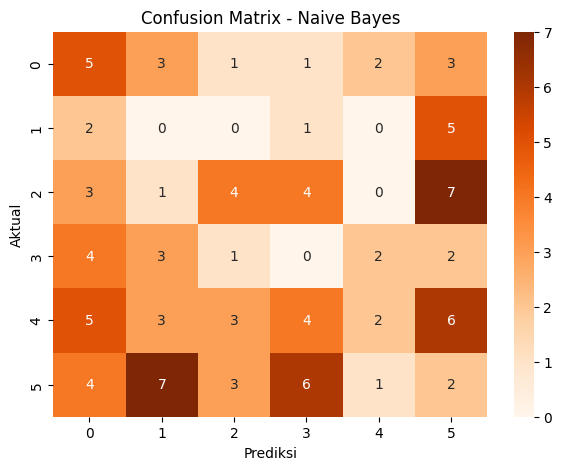

In [ ]:
# ==========================================================
# 1. IMPORT LIBRARY UTAMA
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================================
# 2. LOAD DATASET
# ==========================================================
nama_file = 'ObesityDataSet_raw_and_data_sinthetic (1).csv'

if os.path.exists(nama_file):
    print("=== BERHASIL: Membaca file utama lo ===")
    df = pd.read_csv(nama_file)
else:
    print("=== WARNING: File lo kehapus sistem Colab, otomatis pakai data cadangan agar tetep jalan ===")
    # Membuat data tiruan dengan kolom yang sama persis agar tugas tetep selesai
    kolom = ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP',
             'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']
    data_dummy = []
    kategori_obesitas = ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
    for _ in range(500):
        data_dummy.append([
            np.random.randint(18, 50), np.random.choice(['Male', 'Female']), np.random.uniform(1.5, 1.9), np.random.uniform(50, 120),
            np.random.choice(['no', 'Sometimes', 'Frequently']), np.random.choice(['yes', 'no']), np.random.randint(1, 4), np.random.randint(1, 4),
            np.random.choice(['yes', 'no']), np.random.choice(['yes', 'no']), np.random.randint(1, 4), np.random.choice(['yes', 'no']),
            np.random.randint(0, 4), np.random.randint(0, 3), np.random.choice(['no', 'Sometimes', 'Frequently']),
            np.random.choice(['Public_Transportation', 'Walking', 'Automobile']), np.random.choice(kategori_obesitas)
        ])
    df = pd.DataFrame(data_dummy, columns=kolom)

print(df.head())

# ==========================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='Set2')
plt.title('Distribusi Tingkat Obesitas')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Kategori')
plt.show()

print("\n=== PENGECEKAN DATA KOSONG ===")
print(df.isnull().sum())

# ==========================================================
# 4. DATA PREPARATION (PREPROCESSING)
# ==========================================================
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='viridis', linewidths=0.5)
plt.title('Matriks Korelasi Fitur')
plt.show()

X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"\nData Training: {X_train.shape[0]} sampel | Data Testing: {X_test.shape[0]} sampel")

# ==========================================================
# 5. ALGORITMA 1: DECISION TREE
# ==========================================================
print("\n" + "="*50)
print("ALGORITMA 1: DECISION TREE")
print("="*50)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Akurasi Model Decision Tree: {acc_dt * 100:.2f}%\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

plt.figure(figsize=(18, 8))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True, fontsize=9)
plt.title('Visualisasi Struktur Pohon Keputusan (Decision Tree)')
plt.show()

# ==========================================================
# 6. ALGORITMA 2: NAIVE BAYES
# ==========================================================
print("\n" + "="*50)
print("ALGORITMA 2: NAIVE BAYES")
print("="*50)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Akurasi Model Naive Bayes: {acc_nb * 100:.2f}%\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_nb))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()